In [7]:
#Operational Diagnostics Report & Stakeholder Defens

In [8]:
#1. Data Profiling: Perform a complete univariate and bivariate analysis.

#import relevant libraries for data profiling

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:

#load the dataset
mystery_df = pd.read_csv("/content/ops_sensor_log_cleaned (1).csv")

In [11]:
#display the first 5 rows
mystery_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      4999 non-null   object 
 1   Zone           4999 non-null   object 
 2   Shift          4999 non-null   object 
 3   Pressure_PSI   4999 non-null   float64
 4   Temperature_C  4999 non-null   float64
 5   Flow_Rate_LPM  4999 non-null   float64
dtypes: float64(3), object(3)
memory usage: 234.5+ KB


### Initial Data Overview and Profiling

Before diving into anomaly detection, it's crucial to understand the basic structure and characteristics of our dataset. This section focuses on initial data profiling steps, including:

*   **`mystery_df.info()`**: To get a concise summary of the DataFrame, including data types, non-null values, and memory usage. This helps in identifying potential data type issues or missing data at a glance.
*   **`mystery_df.describe()`**: To generate descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution. This provides insights into the range, mean, median (from 50% percentile), and standard deviation for numerical columns.
*   **`mystery_df.isna().sum()`**: To check for any missing values across all columns. Identifying and handling missing values is a critical prerequisite for accurate analysis.
*   **Distribution Plots (Histograms/Box Plots)**: To visualize the distribution of key numerical variables. This helps in understanding the spread of data and visually identifying potential outliers or anomalies.

In [12]:
#summary statistics, missing value checks, and distribution plots.
mystery_df.describe()

,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,4999.000000,4999.000000,4999.000000
mean,199.636473,64.719000,999.333285
std,46.846478,11.894802,230.629041
min,0.000000,0.000000,600.010000
25%,161.420000,55.165000,800.500000
50%,200.450000,64.760000,996.300000
75%,239.080000,74.300000,1200.035000
max,279.960000,85.000000,1399.760000


In [15]:
#check for the missing values
mystery_df.isna().sum()

,0
timestamp,0
Zone,0
Shift,0
Pressure_PSI,0
Temperature_C,0
Flow_Rate_LPM,0


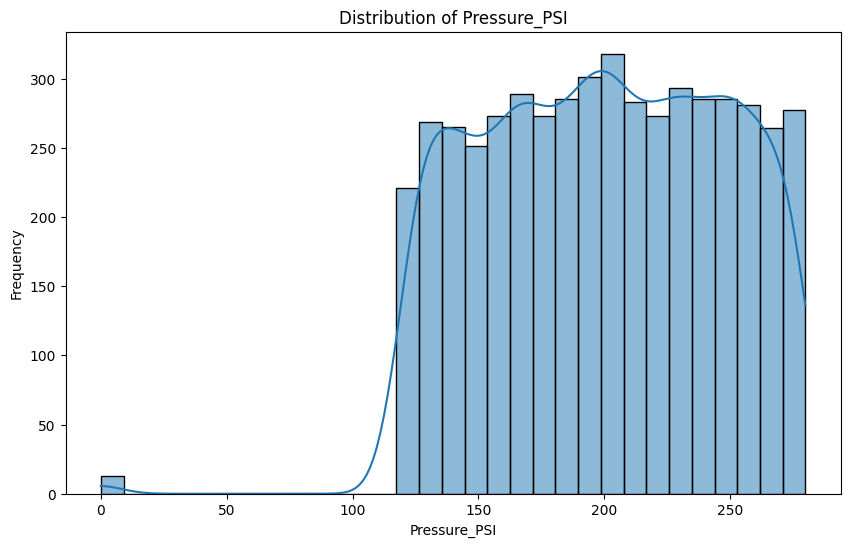

In [19]:
# Plot the distribution of 'Pressure_PSI'
plt.figure(figsize=(10, 6))
sns.histplot(mystery_df['Pressure_PSI'], kde=True)
plt.title('Distribution of Pressure_PSI')
plt.xlabel('Pressure_PSI')
plt.ylabel('Frequency')
plt.show()

In [ ]:
 #Anomaly Detection: Identify at least two significant anomalies or outliers in the data.
 #identify the outliers


In [ ]:
 #identify the outliers


### Anomaly Detection Methodology

To identify anomalies in the sensor data, we will use the **Interquartile Range (IQR) method**. This method is robust to outliers and is commonly used for skewed distributions. The steps are as follows:

1.  **Calculate the First Quartile (Q1)**: This is the 25th percentile of the data.
2.  **Calculate the Third Quartile (Q3)**: This is the 75th percentile of the data.
3.  **Calculate the Interquartile Range (IQR)**: IQR = Q3 - Q1.
4.  **Define Outlier Bounds**:
    *   **Lower Bound**: Q1 - 1.5 * IQR
    *   **Upper Bound**: Q3 + 1.5 * IQR
5.  **Identify Outliers**: Any data points falling below the lower bound or above the upper bound are considered outliers.

We will apply this method to `Pressure_PSI` and `Temperature_C` to detect significant anomalies, specifically focusing on values that are unexpectedly low (e.g., zero readings). Visualizations like box plots will also be used to confirm these findings.

In [30]:
# Calculate Q1, Q3, and IQR for 'Pressure_PSI'
Q1_pressure = mystery_df['Pressure_PSI'].quantile(0.25)
Q3_pressure = mystery_df['Pressure_PSI'].quantile(0.75)
IQR_pressure = Q3_pressure - Q1_pressure

# Define outlier bounds for 'Pressure_PSI'
lower_bound_pressure = Q1_pressure - 1.5 * IQR_pressure
upper_bound_pressure = Q3_pressure + 1.5 * IQR_pressure

# Identify outliers in 'Pressure_PSI'
outliers_pressure = mystery_df[(mystery_df['Pressure_PSI'] < lower_bound_pressure) | (mystery_df['Pressure_PSI'] > upper_bound_pressure)]

print(f"Outliers in Pressure_PSI (below {lower_bound_pressure:.2f} or above {upper_bound_pressure:.2f}):")
display(outliers_pressure)

Outliers in Pressure_PSI (below 44.93 or above 355.57):


,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
302,25/06/2026 10:04,Zone_North,Morning,0.0,64.59,800.53
1843,27/06/2026 13:26,Zone_East,Morning,0.0,56.43,1329.95
1966,27/06/2026 17:32,Zone_South,Afternoon,0.0,56.99,945.43
2040,27/06/2026 20:00,Zone_West,Night,0.0,68.73,995.71
2191,28/06/2026 01:02,Zone_West,Afternoon,0.0,80.25,838.90
3276,29/06/2026 13:12,Zone_South,Night,0.0,68.65,1324.41
3588,29/06/2026 23:36,Zone_South,Night,0.0,72.30,891.97
3669,30/06/2026 02:18,Zone_North,Night,0.0,48.23,917.65
3719,30/06/2026 03:58,Zone_North,Afternoon,0.0,76.82,869.74
3771,30/06/2026 05:42,Zone_South,Night,0.0,77.82,810.17


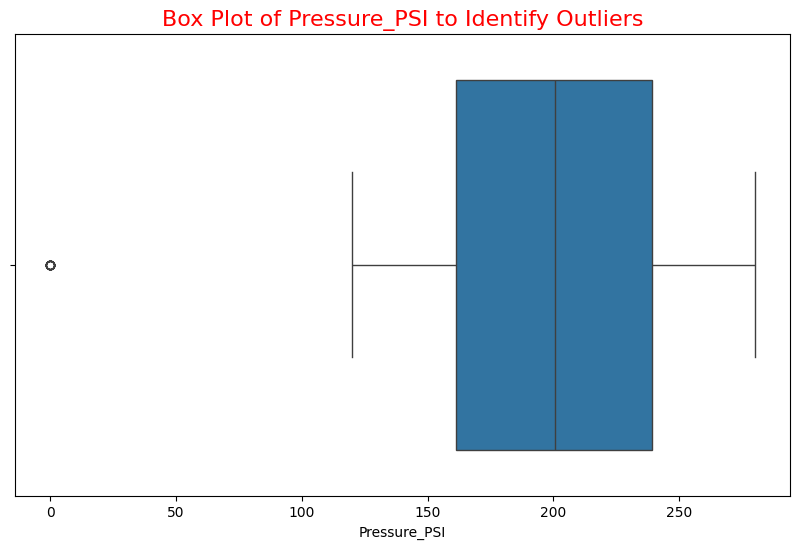

In [62]:
# Visualize outliers in 'Pressure_PSI' using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=mystery_df['Pressure_PSI'])
plt.title('Box Plot of Pressure_PSI to Identify Outliers', color="red", fontsize=16)
plt.xlabel('Pressure_PSI')
plt.show()

In [43]:
# Calculate Q1, Q3, and IQR for 'Temperature_C'
Q1_temp = mystery_df['Temperature_C'].quantile(0.25)
Q3_temp = mystery_df['Temperature_C'].quantile(0.75)
IQR_temp = Q3_temp - Q1_temp

# Define outlier bounds for 'Temperature_C'
lower_bound_temp = Q1_temp - 1.5 * IQR_temp
upper_bound_temp = Q3_temp + 1.5 * IQR_temp

# Identify outliers in 'Temperature_C'
outliers_temp = mystery_df[(mystery_df['Temperature_C'] < lower_bound_temp) | (mystery_df['Temperature_C'] > upper_bound_temp)]

print(f"Outliers in Temperature_C (below {lower_bound_temp:.2f} or above {upper_bound_temp:.2f}):")
display(outliers_temp)

Outliers in Temperature_C (below 26.46 or above 103.00):


,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM,hour,day_of_week,week_of_year
320,2026-06-25 10:40:00,Zone_South,Afternoon,248.92,0.0,1063.92,10,Thursday,26
549,2026-06-25 18:18:00,Zone_South,Afternoon,254.17,0.0,775.12,18,Thursday,26
696,2026-06-25 23:12:00,Zone_West,Night,197.25,0.0,722.11,23,Thursday,26
848,2026-06-26 04:16:00,Zone_North,Night,218.52,0.0,650.46,4,Friday,26
1114,2026-06-26 13:08:00,Zone_East,Night,255.41,0.0,650.79,13,Friday,26
1562,2026-06-27 04:04:00,Zone_Central,Afternoon,204.09,0.0,1185.00,4,Saturday,26
1572,2026-06-27 04:24:00,Zone_North,Morning,158.20,0.0,626.71,4,Saturday,26
2163,2026-06-28 00:06:00,Zone_South,Morning,165.28,0.0,1138.48,0,Sunday,26
2392,2026-06-28 07:44:00,Zone_South,Night,235.46,0.0,723.33,7,Sunday,26
2609,2026-06-28 14:58:00,Zone_North,Morning,155.24,0.0,1002.83,14,Sunday,26


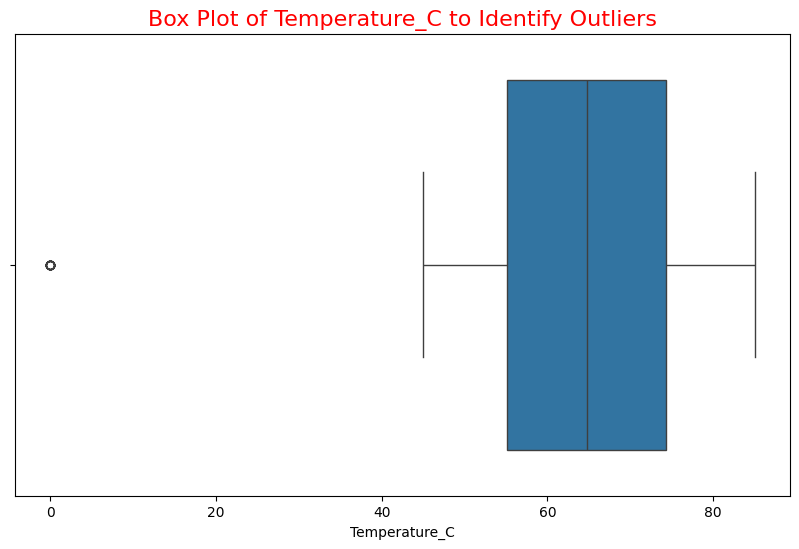

In [63]:
# Visualize outliers in 'Temperature_C' using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=mystery_df['Temperature_C'])
plt.title('Box Plot of Temperature_C to Identify Outliers', color="red", fontsize=16)
plt.xlabel('Temperature_C')
plt.show()

In [41]:
# Calculate Q1, Q3, and IQR for 'Temperature_C'
Q1_temp = mystery_df['Temperature_C'].quantile(0.25)
Q3_temp = mystery_df['Temperature_C'].quantile(0.75)
IQR_temp = Q3_temp - Q1_temp

# Define outlier bounds for 'Temperature_C'
lower_bound_temp = Q1_temp - 1.5 * IQR_temp
upper_bound_temp = Q3_temp + 1.5 * IQR_temp

# Identify outliers in 'Temperature_C'
outliers_temp = mystery_df[(mystery_df['Temperature_C'] < lower_bound_temp) | (mystery_df['Temperature_C'] > upper_bound_temp)]

print(f"Outliers in Temperature_C (below {lower_bound_temp:.2f} or above {upper_bound_temp:.2f}):")
display(outliers_temp)

Outliers in Temperature_C (below 26.46 or above 103.00):


,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM,hour,day_of_week,week_of_year
320,2026-06-25 10:40:00,Zone_South,Afternoon,248.92,0.0,1063.92,10,Thursday,26
549,2026-06-25 18:18:00,Zone_South,Afternoon,254.17,0.0,775.12,18,Thursday,26
696,2026-06-25 23:12:00,Zone_West,Night,197.25,0.0,722.11,23,Thursday,26
848,2026-06-26 04:16:00,Zone_North,Night,218.52,0.0,650.46,4,Friday,26
1114,2026-06-26 13:08:00,Zone_East,Night,255.41,0.0,650.79,13,Friday,26
1562,2026-06-27 04:04:00,Zone_Central,Afternoon,204.09,0.0,1185.00,4,Saturday,26
1572,2026-06-27 04:24:00,Zone_North,Morning,158.20,0.0,626.71,4,Saturday,26
2163,2026-06-28 00:06:00,Zone_South,Morning,165.28,0.0,1138.48,0,Sunday,26
2392,2026-06-28 07:44:00,Zone_South,Night,235.46,0.0,723.33,7,Sunday,26
2609,2026-06-28 14:58:00,Zone_North,Morning,155.24,0.0,1002.83,14,Sunday,26


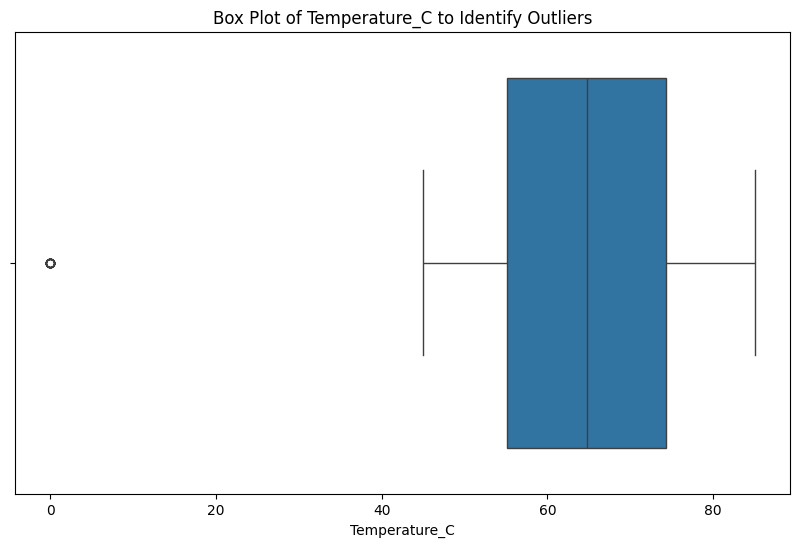

In [42]:
# Visualize outliers in 'Temperature_C' using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=mystery_df['Temperature_C'])
plt.title('Box Plot of Temperature_C to Identify Outliers')
plt.xlabel('Temperature_C')
plt.show()

3. Root Cause Analysis:

### Root Cause Analysis: Drilling Down into Anomalies

With anomalies identified, the next step is to understand *why* and *where* they are occurring. This Root Cause Analysis phase involves:

1.  **Temporal and Spatial Drill-Down**: Examining the distribution of anomalies across different operational dimensions such as `Zone`, `Shift`, and `Day of Week`. This helps pinpoint specific contexts where anomalies are more prevalent.
2.  **Pareto Analysis**: Applying the Pareto principle (80/20 rule) to quantify the impact of the top contributing factors (e.g., zones, shifts) to the total number of anomalies. This helps prioritize investigation efforts.
3.  **Correlation Analysis**: Investigating relationships between different sensor readings to see if anomalies in one variable are associated with unusual patterns in others. This can help confirm or rule out potential drivers. Due to the limited external data, this will focus on internal sensor correlations.

### Pareto Analysis for Anomalies by Shift

### Pareto Analysis by Shift

The Pareto analysis for anomalies by shift helps us determine which shifts contribute most significantly to the total number of anomalies. By combining the anomaly counts for `Pressure_PSI` and `Temperature_C` and then calculating the cumulative percentage, we can identify the shifts responsible for the majority of the issues. The Pareto chart visually represents this, showing both the individual contribution of each shift and their cumulative impact.

Pareto Analysis by Shift:


,Pressure_Anomalies,Temperature_Anomalies,Total_Anomalies,Cumulative_Percentage
Shift,,,,
Night,5,5,10,34.482759
Morning,3,7,10,68.965517
Afternoon,5,4,9,100.000000


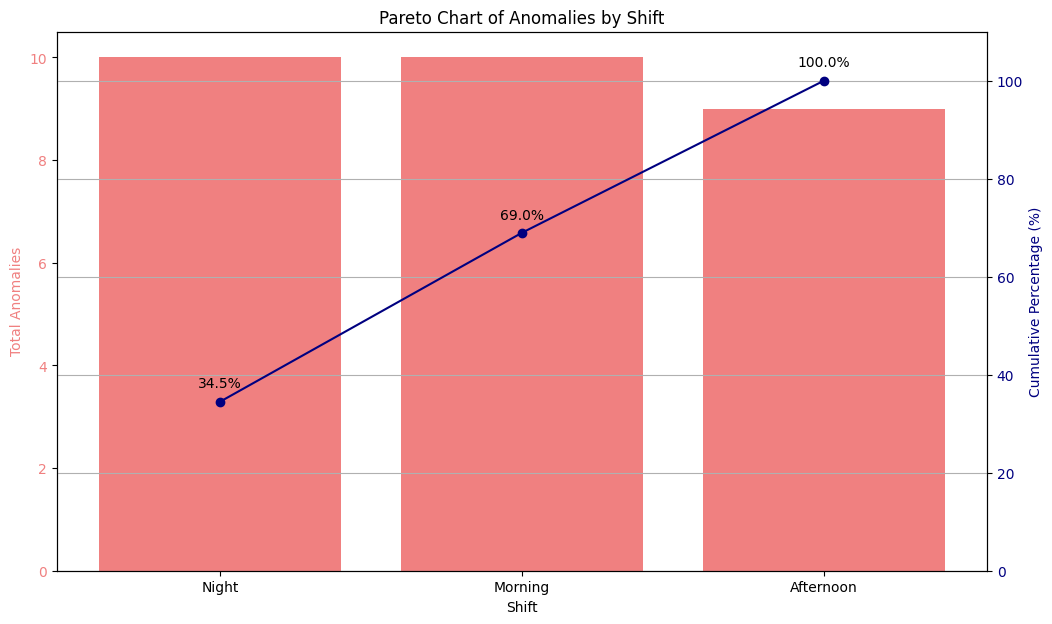

In [50]:
# Combine anomaly counts by Shift
combined_shift_impact = pd.concat([shift_impact_pressure, shift_impact_temp], axis=1, sort=False)
combined_shift_impact.columns = ['Pressure_Anomalies', 'Temperature_Anomalies']
combined_shift_impact = combined_shift_impact.fillna(0).astype(int)
combined_shift_impact['Total_Anomalies'] = combined_shift_impact['Pressure_Anomalies'] + combined_shift_impact['Temperature_Anomalies']

# Sort by Total_Anomalies for Pareto Analysis
pareto_shift = combined_shift_impact.sort_values(by='Total_Anomalies', ascending=False)

# Calculate cumulative percentage
pareto_shift['Cumulative_Percentage'] = (pareto_shift['Total_Anomalies'].cumsum() / pareto_shift['Total_Anomalies'].sum()) * 100

print("Pareto Analysis by Shift:")
display(pareto_shift)

# Plot Pareto Chart
fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.bar(pareto_shift.index, pareto_shift['Total_Anomalies'], color='lightcoral')
ax1.set_xlabel('Shift')
ax1.set_ylabel('Total Anomalies', color='lightcoral')
ax1.tick_params(axis='y', labelcolor='lightcoral')

ax2 = ax1.twinx()
ax2.plot(pareto_shift.index, pareto_shift['Cumulative_Percentage'], color='navy', marker='o', linestyle='-')
ax2.set_ylabel('Cumulative Percentage (%)', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')
ax2.set_ylim(0, 110)

# Add cumulative percentage labels on the line
for i, txt in enumerate(pareto_shift['Cumulative_Percentage']):
    ax2.annotate(f'{txt:.1f}%', (pareto_shift.index[i], pareto_shift['Cumulative_Percentage'].iloc[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Pareto Chart of Anomalies by Shift')
plt.grid(True)
plt.show()

### Correlation Analysis to rule out or confirm potential drivers

### Correlation Analysis

Correlation analysis is performed to understand the relationships between the numerical sensor readings: `Pressure_PSI`, `Temperature_C`, and `Flow_Rate_LPM`. A correlation matrix and a heatmap visualize these relationships. High positive or negative correlations could indicate that changes in one sensor reading are strongly associated with changes in another. Conversely, low correlations suggest that the sensor readings are largely independent. This analysis helps to rule out or confirm if these sensor readings are influencing each other in the context of the identified anomalies.

Correlation Matrix:


,Pressure_PSI,Temperature_C,Flow_Rate_LPM
Pressure_PSI,1.000000,-0.012946,0.005025
Temperature_C,-0.012946,1.000000,0.016982
Flow_Rate_LPM,0.005025,0.016982,1.000000


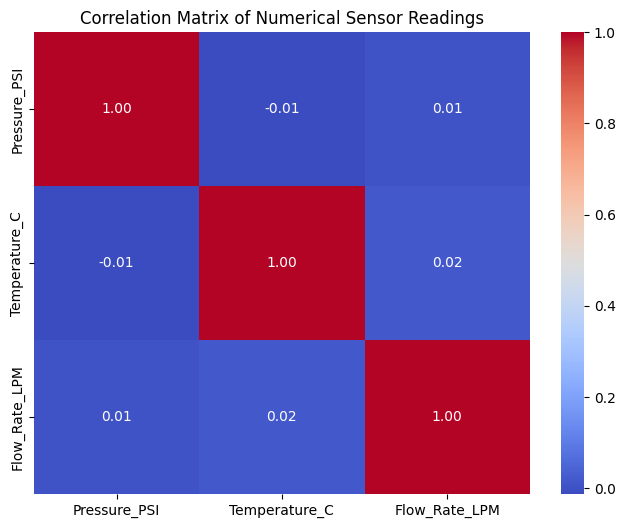

In [53]:
# Select numerical columns for correlation analysis
correlation_df = mystery_df[['Pressure_PSI', 'Temperature_C', 'Flow_Rate_LPM']]

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Sensor Readings')
plt.show()

Visualization

### Anomaly Visualization: Quantifying the Problem

To effectively communicate the findings, it's essential to visualize the anomalies in a clear and compelling manner. This section presents publication-quality charts (using Seaborn and Matplotlib) that summarize the root cause analysis. These charts will illustrate:

1.  **Total Anomalies by Zone**: A bar chart showing the combined count of `Pressure_PSI` and `Temperature_C` anomalies per operational zone, highlighting the most problematic locations.
2.  **Pareto Chart of Anomalies by Shift**: A Pareto chart demonstrating the individual and cumulative contribution of each shift to the total anomalies, emphasizing the shifts with the highest impact.
3.  **Total Anomalies by Day of Week**: A bar chart displaying the combined count of anomalies for each day of the week, identifying any daily patterns or trends.

### Anomaly Visualization: Quantifying the Problem

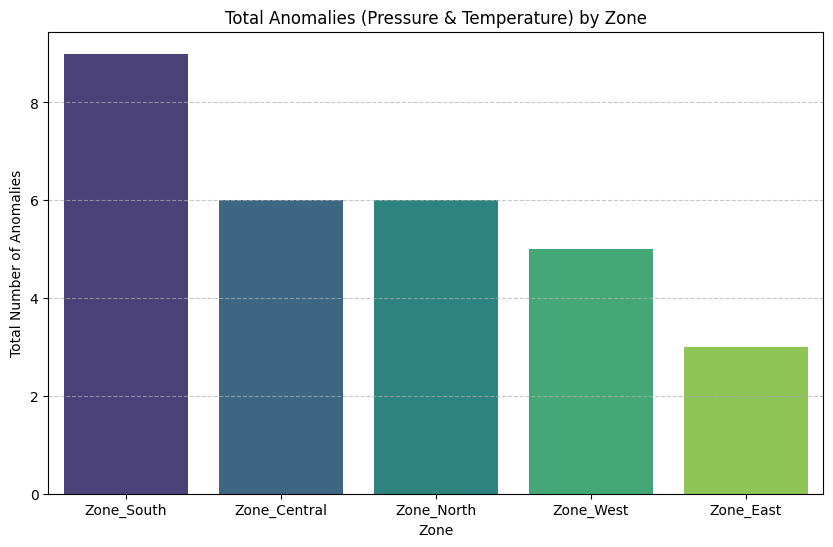

In [57]:
# Combine anomaly counts by Zone
combined_zone_impact = pd.concat([zone_impact_pressure, zone_impact_temp], axis=1, sort=False)
combined_zone_impact.columns = ['Pressure_Anomalies', 'Temperature_Anomalies']
combined_zone_impact = combined_zone_impact.fillna(0).astype(int)
combined_zone_impact['Total_Anomalies'] = combined_zone_impact['Pressure_Anomalies'] + combined_zone_impact['Temperature_Anomalies']

# Sort for better visualization
pareto_zone = combined_zone_impact.sort_values(by='Total_Anomalies', ascending=False)

# Chart 1: Total Anomalies by Zone
plt.figure(figsize=(10, 6))
sns.barplot(x=pareto_zone.index, y='Total_Anomalies', data=pareto_zone, palette='viridis', hue=pareto_zone.index, legend=False)
plt.title('Total Anomalies (Pressure & Temperature) by Zone')
plt.xlabel('Zone')
plt.ylabel('Total Number of Anomalies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

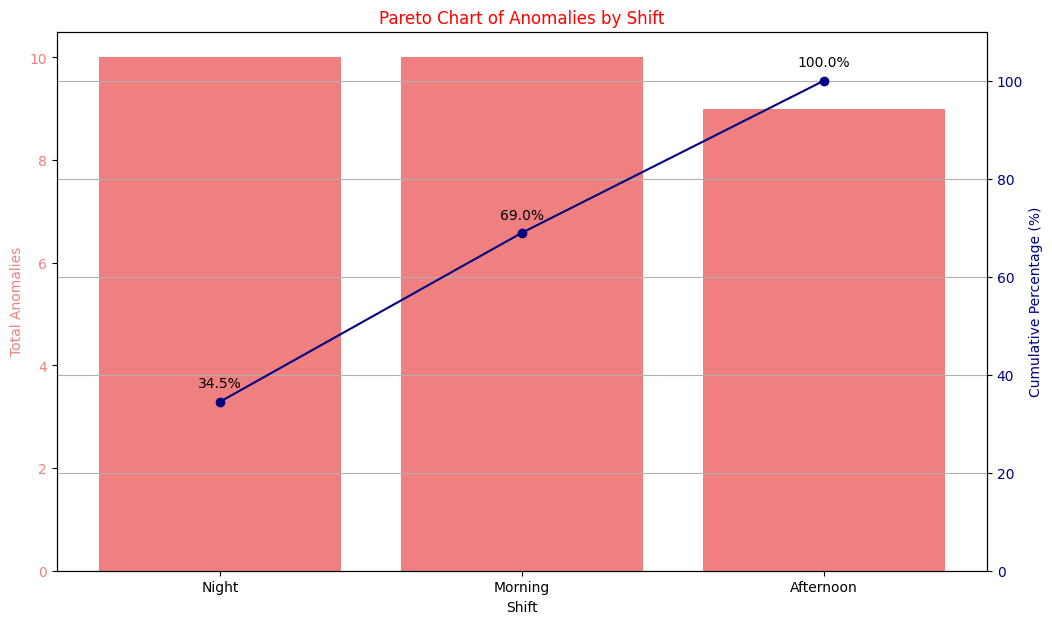

In [61]:
# Chart 2: Total Anomalies by Shift (using already calculated pareto_shift)
# The pareto_shift DataFrame was already created in a previous step.

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.bar(pareto_shift.index, pareto_shift['Total_Anomalies'], color='lightcoral')
ax1.set_xlabel('Shift')
ax1.set_ylabel('Total Anomalies', color='lightcoral')
ax1.tick_params(axis='y', labelcolor='lightcoral')

ax2 = ax1.twinx()
ax2.plot(pareto_shift.index, pareto_shift['Cumulative_Percentage'], color='navy', marker='o', linestyle='-')
ax2.set_ylabel('Cumulative Percentage (%)', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')
ax2.set_ylim(0, 110)

# Add cumulative percentage labels on the line
for i, txt in enumerate(pareto_shift['Cumulative_Percentage']):
    ax2.annotate(f'{txt:.1f}%', (pareto_shift.index[i], pareto_shift['Cumulative_Percentage'].iloc[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Pareto Chart of Anomalies by Shift', color="red")
plt.grid(True)
plt.show()

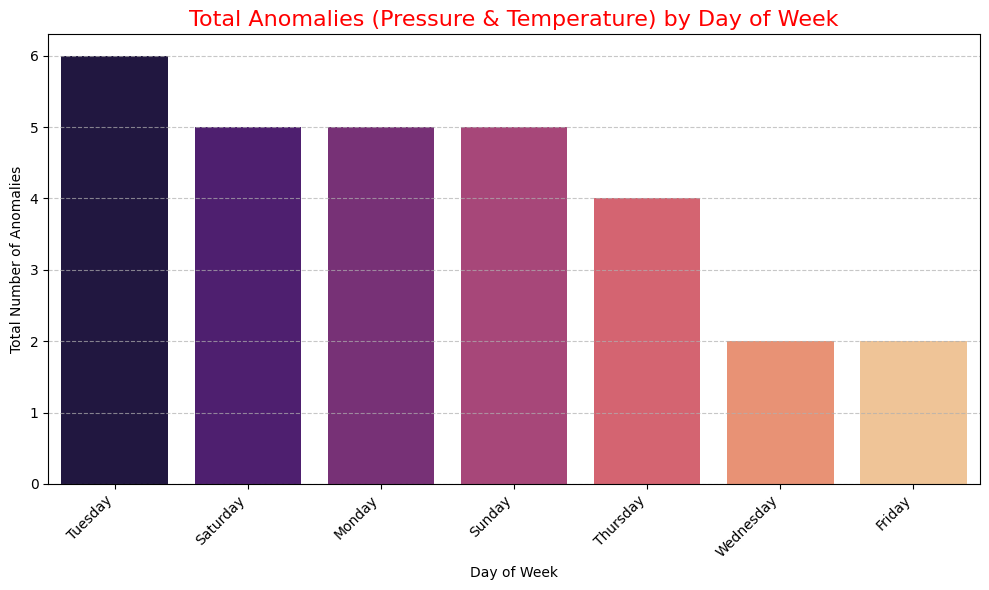

In [60]:
# Combine anomaly counts by Day of Week
combined_day_impact = pd.concat([day_impact_pressure, day_impact_temp], axis=1, sort=False)
combined_day_impact.columns = ['Pressure_Anomalies', 'Temperature_Anomalies']
combined_day_impact = combined_day_impact.fillna(0).astype(int)
combined_day_impact['Total_Anomalies'] = combined_day_impact['Pressure_Anomalies'] + combined_day_impact['Temperature_Anomalies']

# The index 'day_of_week' already contains day names (e.g., 'Tuesday', 'Saturday'),
# so no mapping from numbers to names is needed here, as it was causing a TypeError.

# Sort for better visualization
pareto_day = combined_day_impact.sort_values(by='Total_Anomalies', ascending=False)

# Chart 3: Total Anomalies by Day of Week
plt.figure(figsize=(10, 6))
sns.barplot(x=pareto_day.index, y='Total_Anomalies', data=pareto_day, palette='magma', hue=pareto_day.index, legend=False)
plt.title('Total Anomalies (Pressure & Temperature) by Day of Week', color="red", fontsize=16)
plt.xlabel('Day of Week')
plt.ylabel('Total Number of Anomalies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()